# Week 3: Preprocessing

In this notebook I turn the raw data into a clean dataset I can model on. My goal is to remove leakage, drop columns that are mostly empty or useless, fill in the gaps that are safe to fill, and split the data into training and test sets by time. The output is three CSV files that the modeling notebook will use.

## Setup

I load pandas and numpy for the data work, glob and os for loading the files, and missingno for visualizing missing values. I think missingno is worth adding here, because seeing the gaps as a picture is faster than reading a table.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import missingno as msno

## Load the raw data

I load the raw California files, not the filled ones, and merge them into one DataFrame. I filter again to residential single family homes so this notebook lines up with the exploration notebook.

**Anomaly fix — file filter did nothing:** the year check used to be wrapped in `[ ... ]`, turning it into a one-item list. In Python a non-empty list always counts as "true", no matter what boolean is inside it, so the year filter never actually excluded anything. Changed the brackets to parentheses so it behaves like a real filter again.

In [2]:
data_path = '/Users/danielcai/Downloads/IDXExchange Data Science roles/_/raw/california/california'
all_files = glob.glob(os.path.join(data_path, "CRMLSSold*.csv"))
selected_files = (f for f in all_files if '_filled' not in f and ('2025' in f or '2024' in f or '2026' in f))
# to merge all the files into a single DataFrame
df = pd.concat((pd.read_csv(f, low_memory= False) for f in selected_files), ignore_index=True)
## filtering:
df = df[df['PropertyType'].str.lower() == 'residential']
df = df[df['PropertySubType'].str.lower() == 'singlefamilyresidence']

print(df.shape)
print(df.head())

(230343, 78)
       BuyerAgentAOR  ... MiddleOrJuniorSchoolDistrict
0            Arcadia  ...                          NaN
7   CaliforniaDesert  ...                          NaN
8             Laguna  ...                          NaN
9   PacificSouthwest  ...                          NaN
10  TheInlandGateway  ...                          NaN

[5 rows x 78 columns]


## Remove data leakage

I check the correlation between ListPrice and ClosePrice, and it is nearly one to one. The problem is
that is leakage: the list price already holds most of the answer, so a model using it would look great
and be useless in the real world. My solution is to drop ListPrice completely.

**Update:** the team's AVM best-practices doc flags `OriginalListPrice` the same way — "near-perfect
correlation with ClosePrice; unavailable for off-market homes" — so I'm dropping that here too instead
of leaving it in as a feature. Same doc also calls out Days on Market, price-reduction flags, and
closing/settlement fields as leakage for the same reason (only knowable once a sale has already played
out); DOM is present in this dataset and still in the feature set today, worth a separate pass.

In [3]:
# Check correlation between ListPrice/OriginalListPrice and ClosePrice
print(df[['ListPrice', 'OriginalListPrice', 'ClosePrice']].corr())

# Check how many rows have ListPrice/OriginalListPrice missing
print(f"ListPrice missing: {df['ListPrice'].isnull().sum()}")
print(f"OriginalListPrice missing: {df['OriginalListPrice'].isnull().sum()}")
print(f"ClosePrice missing: {df['ClosePrice'].isnull().sum()}")

# Drop both to avoid data leakage - both are near-perfectly correlated with ClosePrice and
# wouldn't be available for an off-market home anyway
df = df.drop(columns=['ListPrice', 'OriginalListPrice'], errors='ignore')

                   ListPrice  OriginalListPrice  ClosePrice
ListPrice           1.000000           0.201217    0.211813
OriginalListPrice   0.201217           1.000000    0.042250
ClosePrice          0.211813           0.042250    1.000000
ListPrice missing: 0
OriginalListPrice missing: 441
ClosePrice missing: 1


## Drop the columns I do not need

Based on what I found while exploring, I remove columns that add no value. That covers personal details like agent names and emails, constant fields, redundant address text, and duplicate price columns. I think trimming these early keeps the dataset focused and easier to reason about.

In [4]:
print (df.columns)
# since closedprice and listedprice are similar, we should be able to drop one of them.
# From the exploration notebook, we already have a list of dropped variables

cols_to_drop = [
    # Personal identifiers
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
    'CoListAgentFirstName', 'CoListAgentLastName',
    'ListAgentFullName', 'CoListAgentLastName',
    
    # Constant state fields
    'StateOrProvince',
    
    # Redundant address
    'UnparsedAddress',
    
    # Above/Below grade (mostly empty in CA)
    'AboveGradeFinishedArea',
    
    # Brokerage names
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',

    # redundant price field
    'listprice',


]
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columns remaining: {df.shape[1]}")


Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'ListingKey', 'ListAgentEmail',
       'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName',
       'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType',
       'LivingArea', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City',
       'TaxYear', 'BuildingAreaTotal', 'Be

## Handle the missing values

I count and chart how much is missing in each column, then decide what to do. My rule is simple: if a column is almost entirely empty I drop it, and if a blank has a clear meaning I fill it. For example, a missing HOA fee means no HOA, so I fill it with zero. Before dropping BuilderName I pull a new construction flag out of it, so I do not lose that signal.

BuyerAgentAOR                     3682
ListAgentAOR                        36
Flooring                         81990
ViewYN                           20903
WaterfrontYN                    230246
BasementYN                      224687
PoolPrivateYN                    20380
ClosePrice                           1
Latitude                            29
Longitude                           29
LivingArea                         119
FireplacesTotal                 230343
AssociationFeeFrequency         172419
MLSAreaMajor                     33308
TaxAnnualAmount                 230343
ElementarySchool                199353
AttachedGarageYN                 27252
ParkingTotal                         2
BuilderName                     219771
LotSizeAcres                      3966
SubdivisionName                 149884
BuyerOfficeAOR                   14625
YearBuilt                          164
StreetNumberNumeric                281
BathroomsTotalInteger               27
City                     

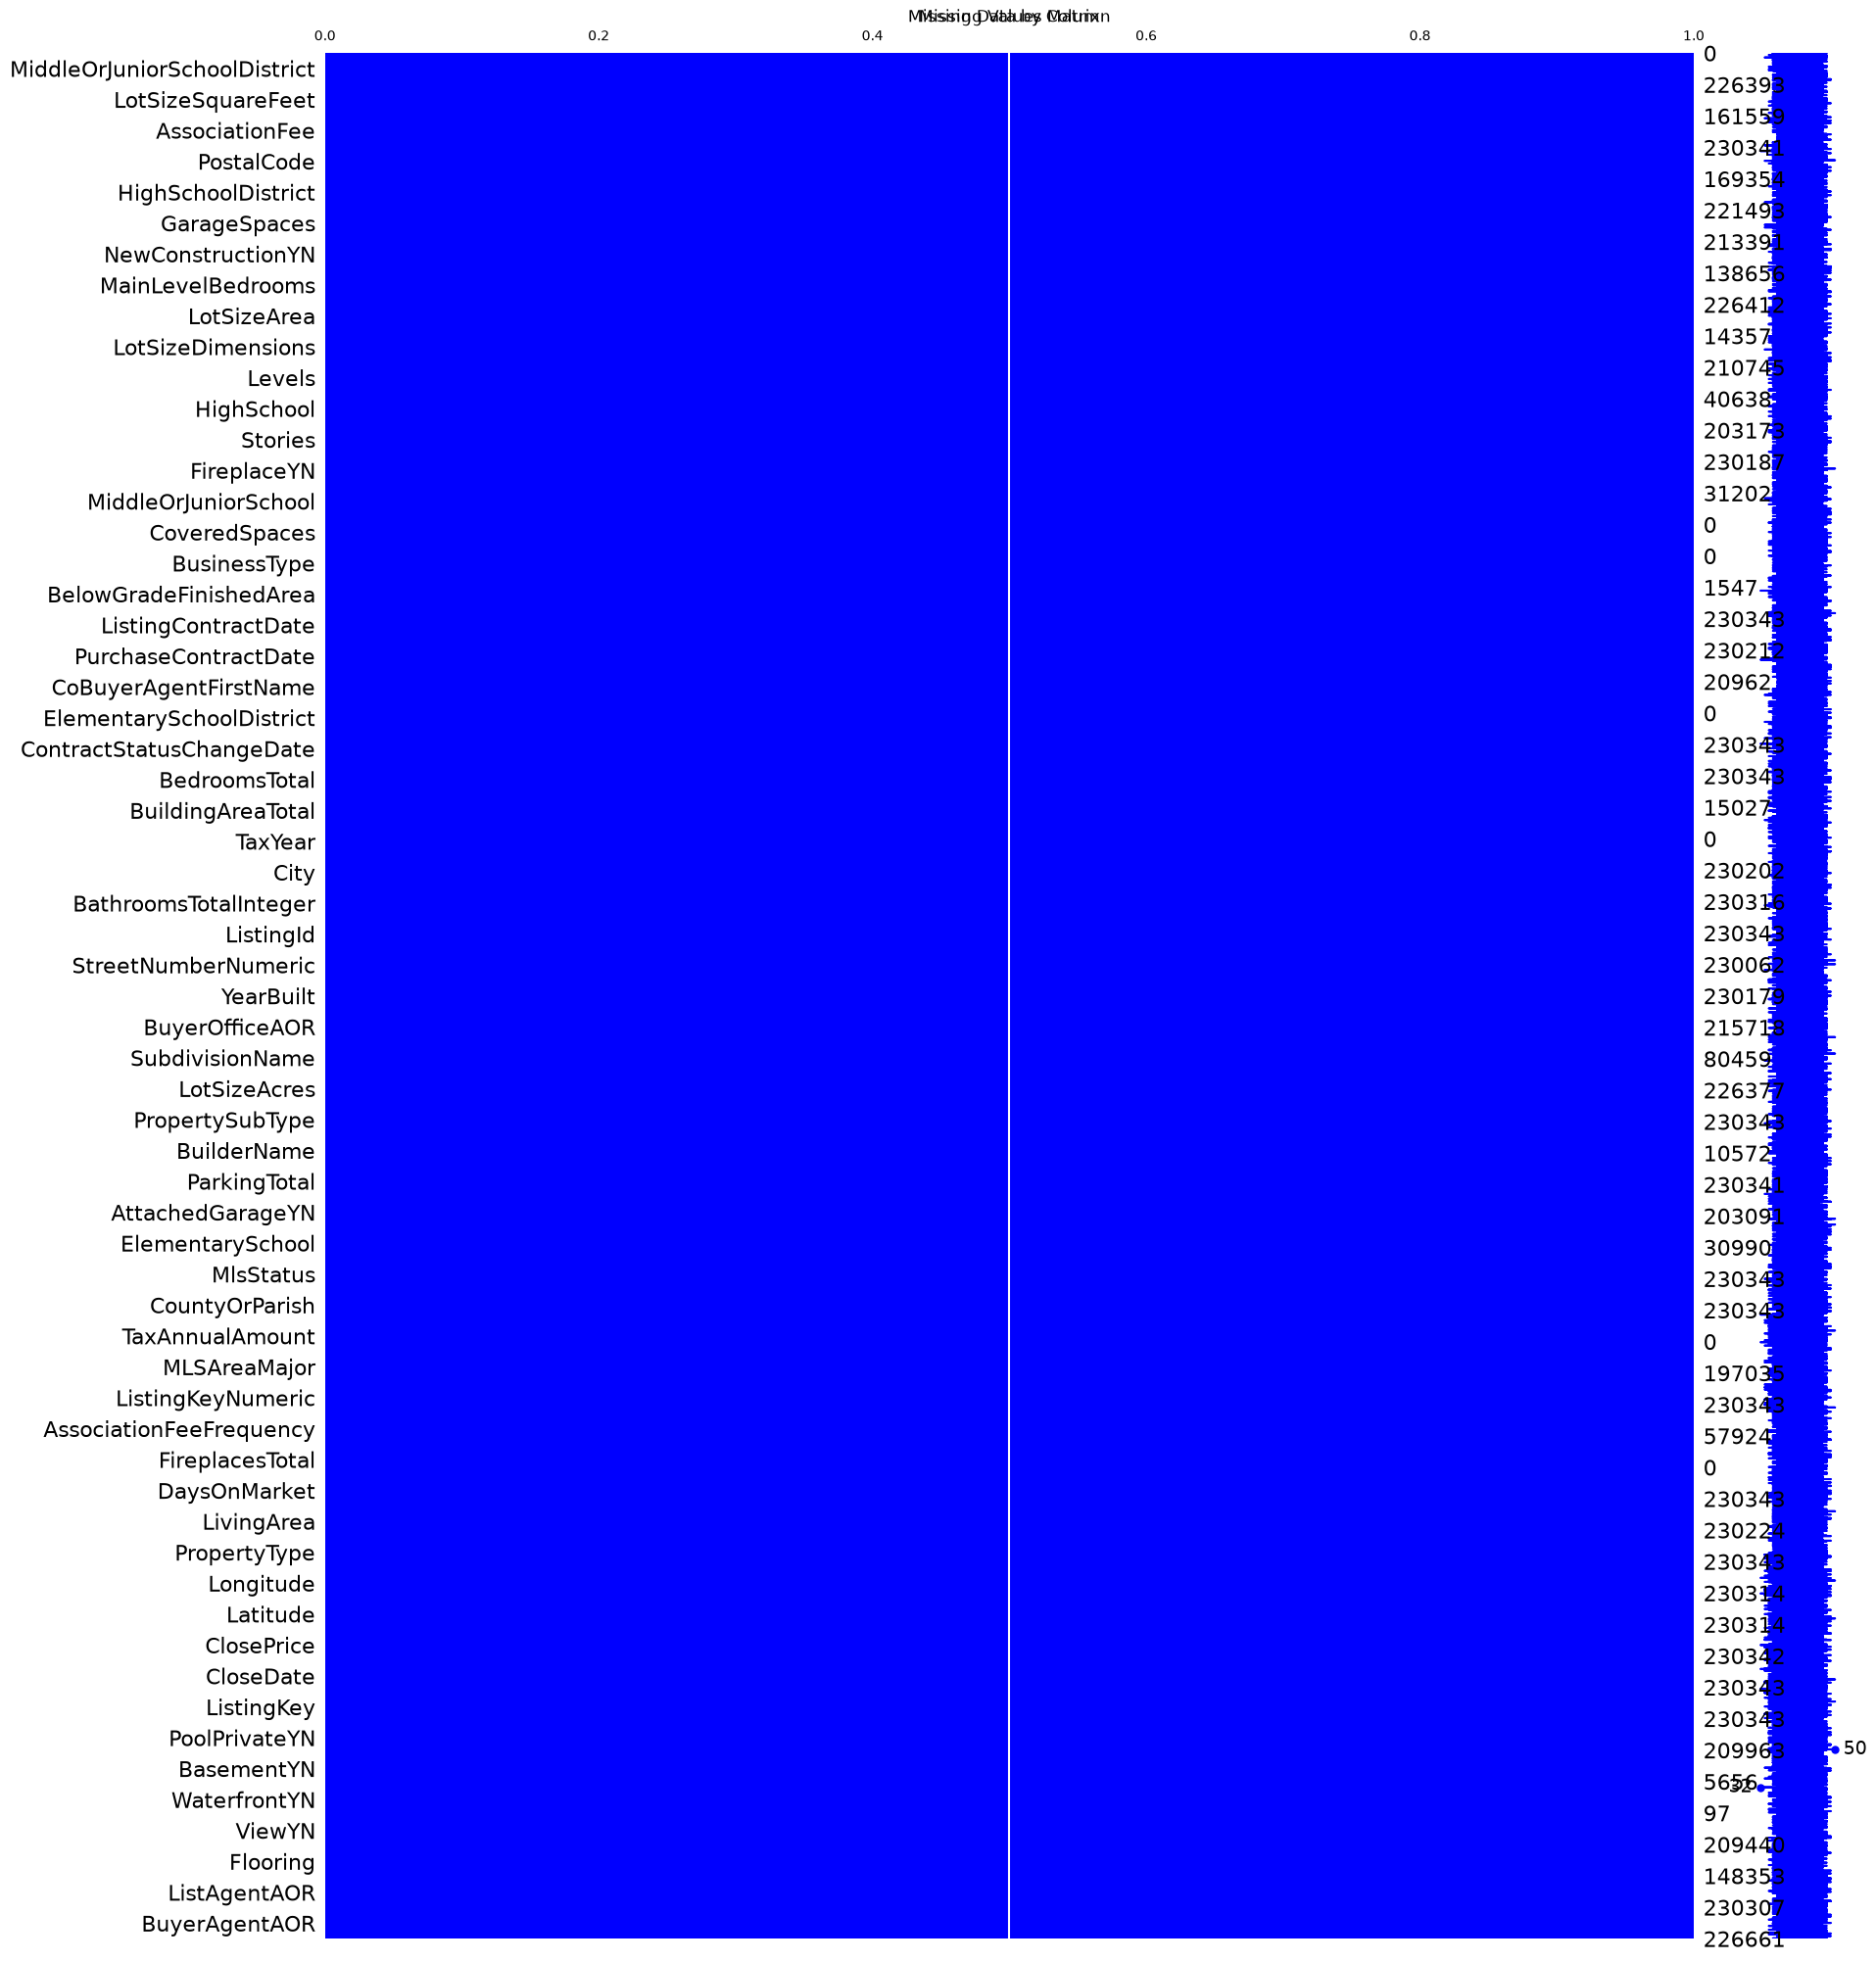

In [5]:
# checking any missing values in the remaining columns
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
missing_pct = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

#Visualize missing values

msno.matrix(df, figsize=(12, 6), color = (0, 0, 1))
plt.title('Missing Values Matrix')
plt.show()


msno.bar(df, figsize=(20, 25 ), color = (0,0,1))
plt.title('Missing Data by Column')
plt.show()

#based on the missing values analysis, we can drop columns that are almost completely missing.
drop_100 = [
    'BusinessType',              # 100% — irrelevant for residential
    'ElementarySchoolDistrict',  # 100% — already have HighSchoolDistrict
    'MiddleOrJuniorSchoolDistrict', # 100% — completely empty
    'FireplacesTotal',           # 100% — completely empty
    'TaxYear',                   # 100% — completely empty
    'CoveredSpaces',             # 100% — flagged for review in your doc
    'TaxAnnualAmount',           # 100% — completely empty
]

drop_high_missing = [
    'WaterfrontYN',              # 99.95% — nearly all missing
    'BelowGradeFinishedArea',    # 99.60% — rare in CA
    'BasementYN',                # 97.61% — rare in CA
    'BuildingAreaTotal',         # 95.38% — redundant with LivingArea
    'BuilderName',               # 95.16% — extract signal first
    'LotSizeDimensions',         # 93.84% — string format, redundant
    'CoBuyerAgentFirstName',     # 91.94% — personal identifier
    'ListAgentAOR',              # 87.99% — low signal
    'BuyerAgentAOR',             # 87.99% — low signal
    'ElementarySchool',          # 85.83% — high cardinality string
    'MiddleOrJuniorSchool',      # 85.53% — high cardinality string
    'HighSchool',                # 81.79% — high cardinality string
]

drop_borderline = [
    'AssociationFeeFrequency',   # 75.84% — redundant with AssociationFee
    'SubdivisionName',           # 65.53% — high cardinality string
    'Flooring',                  # 35.93% — too vague to encode reliably
]

fill_zero = [
    'MainLevelBedrooms',   # 42.12% — missing = no main level bedrooms
    'AssociationFee',      # 30.11% — missing = no HOA
    'NewConstructionYN',   # 21.48% — missing = not new construction
]

all_drops = (
    drop_100 + 
    drop_high_missing + 
    drop_borderline
)

# Extract BuilderName signal before dropping.
# Guarded because BuilderName no longer exists if this cell is re-run without
# restarting the kernel (it gets dropped by all_drops a few lines down) —
# in that case IsNewConstruction was already computed on the first run, so skip it.
if 'BuilderName' in df.columns:
    df['IsNewConstruction'] = (
        df['BuilderName'].notna() | 
        (df['NewConstructionYN'] == 1)
    ).astype(int)

df = df.drop(columns=all_drops, errors='ignore')

# Impute remaining
fill_zero = ['MainLevelBedrooms', 'AssociationFee', 'NewConstructionYN']
for col in fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df['HighSchoolDistrict'] = df['HighSchoolDistrict'].fillna('Unknown')

print(f"Columns remaining: {df.shape[1]}")
print(f"Remaining missing: {df.isnull().sum().sum()}")


#handle impossible data
# For example, negative values for bedrooms, bathrooms, or square footage are impossible
impossible_cols = ['MainLevelBedrooms', 'AssociationFee', 'NewConstructionYN']
for col in impossible_cols:
    if col in df.columns:
        df = df[df[col] >= 0]

# CloseDate earlier than the list date (ListingContractDate) is impossible
before = len(df)
df = df[pd.to_datetime(df['CloseDate']) >= pd.to_datetime(df['ListingContractDate'])]
print(f"Dropped {before - len(df)} rows where CloseDate was before ListingContractDate")

#zero or negative square footage (allow NaN, that gets imputed later)
df = df[(df['LivingArea'] > 0) | df['LivingArea'].isna()]
df = df[(df['LotSizeSquareFeet'] > 0) | df['LotSizeSquareFeet'].isna()]

# a single family home with 0 bathrooms is also impossible data, and dividing by it below
# would blow the ratio up to inf, so drop those rows too (keep missing values as-is)
before = len(df)
df = df[(df['BathroomsTotalInteger'] > 0) | df['BathroomsTotalInteger'].isna()]
print(f"Dropped {before - len(df)} rows with 0 bathrooms")

#bedroom/bathroom counts inconsistent with living area, first show the average 75th and 25th percentile of living area to bathroom ratio

bathroom_ratio = df['LivingArea'] / df['BathroomsTotalInteger']
print(f"Average living area to bathroom ratio: {bathroom_ratio.mean()}")
print(f"75th percentile: {bathroom_ratio.quantile(0.75)}")
print(f"25th percentile: {bathroom_ratio.quantile(0.25)}")

    


## Split by time

I split the data using the close date instead of splitting at random. The most recent month becomes the test set and everything earlier becomes training. I think this is the honest way to test a price model, because in real use I am always predicting the future from the past. I also pull the month, quarter, and year out of the date so the model can still use timing.

**Anomaly fix — time features were getting dropped:** `close_month`, `close_quarter`, and `close_year` used to be created *after* the train/test split and after `X_train`/`X_test` were already built. Since `train_df`/`test_df` are copies taken earlier, those three columns never carried over — they only ended up in `cleaned_housing.csv`, not in `train_housing.csv` or `test_housing.csv`. Moved the extraction to right after `CloseDate` is parsed, before anything is split off, so every downstream file gets them.

In [6]:
#Train/test split

df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Extract time signals now, before the split, so month/quarter/year survive into
# train_df/test_df and the saved CSVs (previously this ran after the split and was lost)
df['close_month'] = df['CloseDate'].dt.month
df['close_quarter'] = df['CloseDate'].dt.quarter
df['close_year'] = df['CloseDate'].dt.year

# Check what months you have
print(df['CloseDate'].dt.to_period('M').value_counts().sort_index())
print(f"\nEarliest: {df['CloseDate'].min()}")
print(f"Latest: {df['CloseDate'].max()}")

# Identify the most recent month
latest_month = df['CloseDate'].dt.to_period('M').max()
print(f"Test month: {latest_month}")

# Split
test_df = df[df['CloseDate'].dt.to_period('M') == latest_month]
train_df = df[df['CloseDate'].dt.to_period('M') != latest_month]

print(f"Train size: {train_df.shape}")
print(f"Test size: {test_df.shape}")
print(f"Test %: {len(test_df)/len(df)*100:.1f}%")

# Drop columns not used as features
drop_from_features = [
    'CloseDate',
    'ClosePrice',        # target variable
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
]

feature_cols = [col for col in df.columns if col not in drop_from_features]

X_train = train_df[feature_cols]
y_train = train_df['ClosePrice']

X_test = test_df[feature_cols]
y_test = test_df['ClosePrice']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Make sure test dates are all after train dates
print(f"Latest train date: {train_df['CloseDate'].max()}")
print(f"Earliest test date: {test_df['CloseDate'].min()}")



CloseDate
2024-08    12416
2024-09    10895
2024-10    12332
2024-11    10681
2024-12    10609
2025-02     8837
2025-03    10596
2025-04    11863
2025-05    11747
2025-06    11686
2025-07    12099
2025-08    11435
2025-09    11440
2025-10    12015
2025-11     9732
2025-12    10439
2026-01     7477
2026-02     8536
2026-03    11164
2026-04    12012
2026-05    12006
Freq: M, Name: count, dtype: int64

Earliest: 2024-08-01 00:00:00
Latest: 2026-05-31 00:00:00
Test month: 2026-05
Train size: (218011, 43)
Test size: (12006, 43)
Test %: 5.2%
X_train shape: (218011, 38)
X_test shape: (12006, 38)
y_train shape: (218011,)
y_test shape: (12006,)
Latest train date: 2026-04-30 00:00:00
Earliest test date: 2026-05-01 00:00:00


## Save the clean data

I save the full cleaned dataset plus the separate train and test files. This way the modeling notebook can just load them and start, and I do not have to rerun all the cleaning every time.

In [7]:
# Save cleaned data
df.to_csv('cleaned_housing.csv', index=False)
print("Saved!")

train_df.to_csv('train_housing.csv', index=False)
test_df.to_csv('test_housing.csv', index=False)
print(f"Train saved: {train_df.shape}")
print(f"Test saved: {test_df.shape}")

Saved!
Train saved: (218011, 43)
Test saved: (12006, 43)
